In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import numpy as np
import seaborn as sns


In [3]:

train_data=pd.read_csv('../input/titanic/train.csv')
test_data=pd.read_csv('../input/titanic/test.csv')
sample=pd.read_csv('../input/titanic/gender_submission.csv')


In [4]:
sample

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [5]:
sample.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [6]:
# train_data[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

<AxesSubplot:xlabel='Sex', ylabel='Survived'>

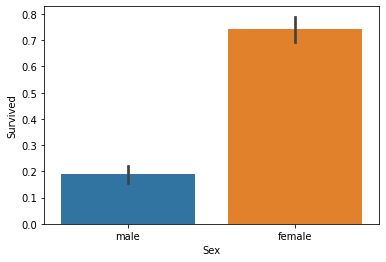

In [7]:
sns.barplot(x="Sex", y="Survived", data=train_data)

In [8]:
print(train_data.shape)
print(test_data.shape)

(891, 12)
(418, 11)


In [9]:
train_data.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [10]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


<AxesSubplot:xlabel='SibSp', ylabel='Age'>

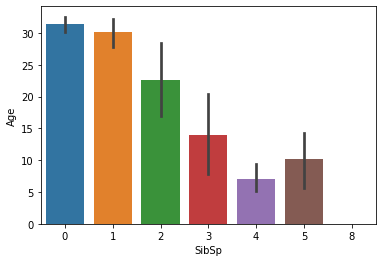

In [11]:
sns.barplot(x="SibSp", y="Age", data=train_data)

In [12]:
print(train_data.isna().sum())
print(test_data.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [13]:
train_data=train_data.drop(['Name','Ticket','Cabin'] , axis=1)
test_data=test_data.drop(['Name','Ticket','Cabin'] , axis=1)

In [14]:
train_data['Embarked']=train_data['Embarked'].map({ 'S':2,
                      'Q' : 1  ,
                       'C': 0
})

test_data['Embarked']=test_data['Embarked'].map({ 'S':2,
                      'Q' : 1  ,
                       'C': 0
})

In [15]:
test_data['Sex']=test_data['Sex'].map({ 'female':1,
                      'male' : 0    
})

train_data['Sex']=train_data['Sex'].map({ 'female':1,
                      'male' : 0    
})

In [16]:
print(train_data.isna().sum())
print(test_data.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64
PassengerId     0
Pclass          0
Sex             0
Age            86
SibSp           0
Parch           0
Fare            1
Embarked        0
dtype: int64


In [17]:
train_data['Age'].fillna(value=train_data['Age'].mean()-(0.2*train_data['SibSp']), inplace=True)
test_data['Age'].fillna(value=test_data['Age'].mean()-(0.2*test_data['SibSp']), inplace=True)

In [18]:
train_data[['Age','SibSp']].corr()

,Age,SibSp
Age,1.00000,-0.23997
SibSp,-0.23997,1.00000


In [19]:
train_data.isna().sum()


PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       2
dtype: int64

In [20]:
test_data.isna().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           1
Embarked       0
dtype: int64

In [21]:
test_data.loc[test_data.Fare.notnull()]

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,0,34.50000,0,0,7.8292,1
1,893,3,1,47.00000,1,0,7.0000,2
2,894,2,0,62.00000,0,0,9.6875,1
3,895,3,0,27.00000,0,0,8.6625,2
4,896,3,1,22.00000,1,1,12.2875,2
...,...,...,...,...,...,...,...,...
413,1305,3,0,30.27259,0,0,8.0500,2
414,1306,1,1,39.00000,0,0,108.9000,0
415,1307,3,0,38.50000,0,0,7.2500,2
416,1308,3,0,30.27259,0,0,8.0500,2


In [22]:
train_data.dropna(inplace=True)

# class_of_fare=test_data.loc[test_data.Fare.isna(),'Pclass']
# value=test_data.loc[(test_data.Fare.notnull()) & ('Pclass'==3)].groupby('Pclass').agg({'Fare':'mean'})
test_data['Fare'].fillna(value=9, inplace=True)

In [23]:
value=test_data.loc[(test_data.Fare.notnull()) & ('Pclass'==3)].groupby('Pclass').agg({'Fare':'mean'})

In [24]:
train_data.isna().sum()



PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [25]:
test_data.isna().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [26]:

# y=train_data['Survived']

In [27]:

train_data
# X=train_data.drop(['Survived' ,'PassengerId'], axis=1)
features = ["Pclass", "Sex", "Age", "Parch",'SibSp']
X=train_data[features]
y=train_data['Survived']
X_test=test_data.drop('PassengerId', axis=1)

In [28]:
# logreg=LogisticRegression()
# logreg.fit(X,y)
# y_pred1=logreg.predict(X_test)

In [29]:
# logreg.score(X,y)

In [30]:
# from sklearn.tree import DecisionTreeClassifier
# d_tree = DecisionTreeClassifier()
# d_tree.fit(X, y)
# Y_pred = d_tree.predict(X_test)
# d_tree.score(X,y)

In [31]:
# from sklearn import preprocessing
# X = preprocessing.normalize(X)
# y = preprocessing.normalize(y)

X=(X-X.min())/(X.max()-X.min())

X


,Pclass,Sex,Age,Parch,SibSp
0,1.0,0.0,0.271174,0.000000,0.125
1,0.0,1.0,0.472229,0.000000,0.125
2,1.0,1.0,0.321438,0.000000,0.000
3,0.0,1.0,0.434531,0.000000,0.125
4,1.0,0.0,0.434531,0.000000,0.000
...,...,...,...,...,...
886,0.5,0.0,0.334004,0.000000,0.000
887,0.0,1.0,0.233476,0.000000,0.000
888,1.0,1.0,0.365407,0.333333,0.125
889,0.0,0.0,0.321438,0.000000,0.000


In [32]:
# from sklearn.feature_selection import SequentialFeatureSelector
# from sklearn.neighbors import KNeighborsClassifier


# knn = KNeighborsClassifier(n_neighbors=18, weights='uniform',leaf_size=1)
# sfs = SequentialFeatureSelector(knn, n_features_to_select=4)
# sfs.fit(X, y)

# sfs.get_support()
# sfs.transform(X).shape


In [33]:
# X.loc[:,sfs.get_support()]

In [34]:
# sfs.get_support()
# knn.fit(X.loc[:,sfs.get_support()],y)

In [35]:
# y_knn_pred=knn.predict(X_test.loc[:,sfs.get_support()])

In [36]:
# knn.score(X.loc[:,sfs.get_support()],y)

In [37]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=2)
model.fit(X,y)
predictions = model.predict(X_test[features])


In [38]:
model.score(X,y)

0.8278965129358831

In [39]:

sample['Survived'] = predictions
sample.to_csv('submission.csv', index=False)

In [40]:
predictions

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [41]:
sample.shape

(418, 2)